# Barcelona Socio-Economic Analysis: Population Nationality and Disposable Income

## Overview




For the first part of the analysis, explores two elements of the socio-economic structure of Barcelona. The population by nationality, and the disposable income per capita. To carry out this analysis, three datasets from Barcelona's Open Data Service are used: 2022 Population by nationality (Spain/EU/Rest of foreign) and sex[<sup>1</sup>](#_blank "Available at: https://opendata-ajuntament.barcelona.cat/data/dataset/pad_mdbas_nacionalitat-g_sexe/resource/0d28f16c-c3de-46ba-99d4-1388e0247bfe"), 2022 Disposable income of households per capita(€) in the city of Barcelona[<sup>2</sup>](#_blank "Available at: https://opendata-ajuntament.barcelona.cat/data/dataset/78db0c75-fa56-4604-9510-8b92834a7fd2"), and the boundaries for administrative units of the city of Barcelona[<sup>3</sup>](#_blank "Available at: https://opendata-ajuntament.barcelona.cat/data/dataset/808daafa-d9ce-48c0-925a-fa5afdb1ed41").

## Socio-Economic Overview of Barcelona

In [20]:
# Importing the required packages
import pandas as pd
import geopandas as gpd
from libpysal import graph
import numpy as np
import seaborn as sns
import esda
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy import stats
from sklearn import cluster, preprocessing

In [21]:
## Loading the datasets
# URLs for the datasets
url_pop_nationality = "https://opendata-ajuntament.barcelona.cat/data/dataset/ae5116f1-b265-4602-9031-edd9a45f342b/resource/486e10e9-c22c-4418-8467-271fe51b2add/download"
url_income = "https://opendata-ajuntament.barcelona.cat/data/dataset/78db0c75-fa56-4604-9510-8b92834a7fd2/resource/3df0c5b9-de69-4c94-b924-57540e52932f/download/2022_renda_disponible_llars_per_persona.csv"
url_adm_units_bcn = "https://opendata-ajuntament.barcelona.cat/data/dataset/808daafa-d9ce-48c0-925a-fa5afdb1ed41/resource/11851135-6919-4dcb-91ed-821e5e87a428/download"

# Read datasets from URLs
pop_nationality_raw = pd.read_csv(url_pop_nationality)
income_bcn_raw = pd.read_csv(url_income)
# reading the seccio censal administrative units from the administrative units dataset
adm_units_bcn_raw = gpd.read_file(
    url_adm_units_bcn, layer="0301040100_SecCens_UNITATS_ADM"
)

In [22]:
# Creating a copy of the raw datasets to work with
pop_nationality = pop_nationality_raw.copy()
income_bcn = income_bcn_raw.copy()
adm_units_bcn = adm_units_bcn_raw.copy()

## Pre-processing Population by nationality
### Creating a field for the join with the spatial data
pop_nationality["code_sec"] = (
    pop_nationality["Seccio_Censal"].astype("str").str.rjust(5, "0")
)
### Converting the number of people to a number
pop_nationality["Valor"] = (
    pop_nationality["Valor"].str.replace(".", "0", regex=False).astype("float")
)

# Creating an aggregated dataframe with the proportion of nationalities per census section
agg_nationality = (
    pop_nationality.groupby(["code_sec", "NACIONALITAT_G"])
    .agg({"Valor": "sum"})
    .reset_index()
)


### Calculating percentages of nationalities by census section
agg_nationality["proportion"] = 100 * (
    agg_nationality["Valor"]
    / agg_nationality.groupby("code_sec")["Valor"].transform("sum")
)


# Creating a dictionary to map the nationality codes to their respective names (based on definitions from
# Dimensions dels conjunts de dades del Padró Municipal d'habitants de la ciutat de Barcelona available at:
# https://opendata-ajuntament.barcelona.cat/data/ca/dataset/pad-dimensions/resource/b00be3f8-9328-4175-8689-24a25bc0907c)

nationality_mapping = {
    1: "Spanish",
    2: "European (excluding Spain)",
    3: "Rest of the world",
    4: "Unspecified",
}

# Mapping the codes to names
agg_nationality["Nationality"] = agg_nationality["NACIONALITAT_G"].map(
    nationality_mapping
)

# Creating a dataset with total population per census section
agg_total_pop = pop_nationality.groupby("code_sec").agg({"Valor": "sum"}).reset_index()
agg_total_pop = agg_total_pop.rename(columns={"Valor": "total_population"})

# Summary statistics for the distribution of Nationality and Sex
desc_nat = agg_nationality.groupby("Nationality")["proportion"].describe()

# Transforming the aggregated nationality dataframe to have one row per census section
agg_nationality = agg_nationality.pivot_table(
    index="code_sec",
    columns="Nationality",
    values="proportion",
).reset_index()

# Calculating the standardised values for each nationality as new columns
for col in ["Spanish", "European (excluding Spain)", "Rest of the world", "Unspecified"]:
    agg_nationality[col + "_std"] = preprocessing.robust_scale(agg_nationality[[col]])

## Pre-processing Income data
### Creating a field for the join with the spatial data from the district code and seccio censal
income_bcn["code_sec"] = income_bcn["Codi_Districte"].astype("str").str.rjust(
    2, "0"
) + income_bcn["Seccio_Censal"].astype("str").str.rjust(3, "0")

## merging the aggregated total population data with the income data
income_bcn = income_bcn.merge(agg_total_pop, on="code_sec", how="left")

# calculating weighted average income per capita in Barcelona
avg_income_per_capita = (
    sum(income_bcn["Import_Euros"] * income_bcn["total_population"])
    / income_bcn["total_population"].sum()
)

income_bcn["Income_std"] = preprocessing.robust_scale(income_bcn[["Import_Euros"]])

# Pre-processing the administrative units data
# Creating a code for the census areas based on
adm_units_bcn["code_sec"] = adm_units_bcn["DISTRICTE"] + adm_units_bcn["SEC_CENS"]

# Join the datasets with the spatial data
join_bcn = adm_units_bcn[["code_sec", "geometry"]].copy()

# Merge income data
join_bcn = join_bcn.merge(
    income_bcn[
        [
            "code_sec",
            "Nom_Barri",
            "Import_Euros",
            "Income_std",
        ]
    ],
    on="code_sec",
    how="left",
)

# Merge nationality proportions
join_bcn = join_bcn.merge(agg_nationality, on="code_sec", how="left").set_index("code_sec")

Among the three main nationality categories, Spanish nationals form the majority across the city, followed by nationals from non-European countries, and then European nationals, with 78%, 16% and 6% of the total population, respectively. A very small portion of the population did not report their nationality (less than 0.5%); this category was excluded from further analysis.

When looking at the spatial distributions, Spanish nationals predominate in most areas, except for locations in the Gothic area and *el Raval*, where higher proportions of non-Spanish nationals are evidenced. European nationals show a consistent distribution across the city, with higher concentrations around the central part of the city, and the western parts of the city. While the proportion of nationals from non-European countries is also relatively high around the centre of the city, some specific areas standout  as the proportion of non-european nationals is the highest among all three categories.

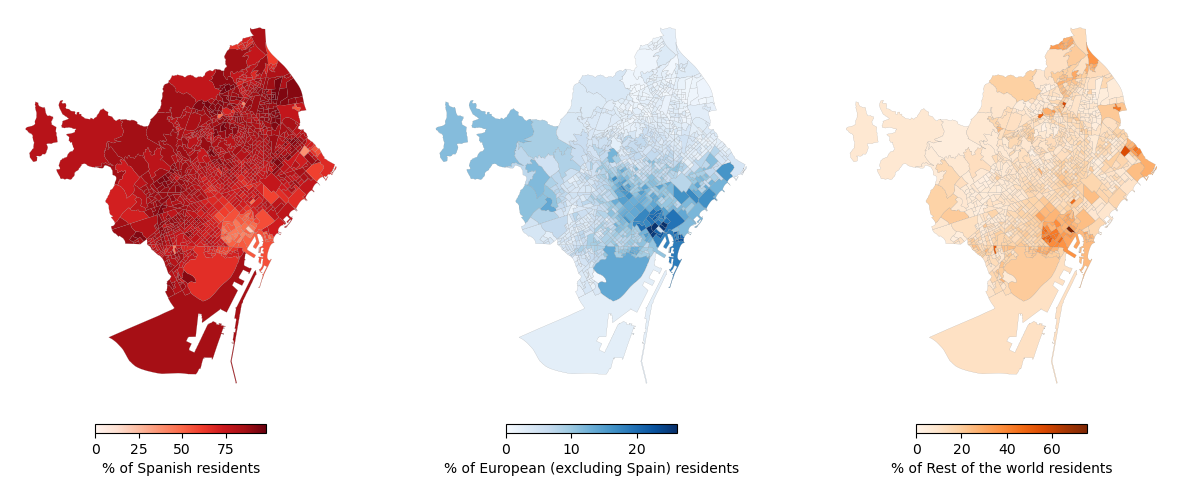

In [24]:
# creating a correspondence for colour maps
cmap_dict = {
    "Spanish": "Reds",
    "European (excluding Spain)": "Blues",
    "Rest of the world": "Oranges",
}

# an arranged grid of maps to show the spatial distribution of population of different nationalities
fig, axes = plt.subplots(1, 3, figsize=(15, 15))
nationalities = ["Spanish", "European (excluding Spain)", "Rest of the world"]
for ax, nationality in zip(axes.flatten(), nationalities):
    join_bcn.plot(
        column= (nationality),
        # a different colormap for each nationality
        cmap=cmap_dict[nationality],
        norm=colors.Normalize(vmin=0),
        edgecolor="gray",  # Borderline color
        linewidth=0.1,  # Borderline width,
        ax=ax,
        legend=True,
        legend_kwds={
            "orientation": "horizontal",
            "shrink": 0.5,
            "pad": 0.02,
            "label": f"% of {nationality} residents",
        },
    )
    ax.set_axis_off()

The mean disposable income per capita in 2022 was estimated at €23,000. As shown in the map below, there are clear spatial differences in income levels across Barcelona. Areas with disposable incomes up to 1.8 times the average are concentrated in the western parts of the city, such as *Sarria*, *Sant Gervasi*, and *Les Tres Torres*. In contrast, lower income levels are more prevalent in the southern and northern areas, where disposable income is around half the city average.

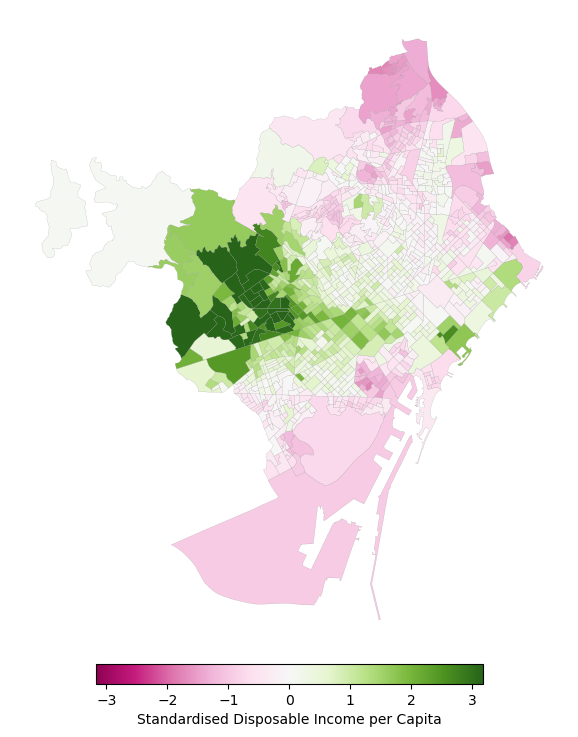

In [25]:
# Visualising the spatial distribution of disposable income ratio
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
join_bcn.plot(
    column="Income_std",
    ax=ax,
    cmap="PiYG",
    edgecolor="gray",  # Borderline color
    linewidth=0.1,  # Borderline width,
    legend=True,
    norm=colors.CenteredNorm(vcenter=0),
    legend_kwds={
        "orientation": "horizontal",
        "shrink": 0.5,
        "pad": 0.02,
        "label": "Standardised Disposable Income per Capita",
    },
)
ax.set_axis_off()

## Is there spatial autocorrelation in income and population by nationality?

The maps presented before may suggest that the spatial distributions of income and nationalities in Barcelona are not a result of a random process, i.e. people with similar incomes tend to be close to each other, and people from other nationalities might tend to locate themselves in areas with more diverse populations.

To formally test this, spatial autocorrelation statistics were calculated for both the disposable income and the population.First, a spatial weights matrix was constructed using Queen contiguity, so each census area was assumed to be related to others which share a boundary or vertex, resulting in a median number of neighbors of 6 per census area, with some having up to 23 neighbors and others as few as 2. 

Second, the spatially lagged variables were computed using this weights matrix; and Moran's I statistics were calculated to assess the overall degree of spatial autocorrelation. As 
shown in the table below, both disposable income and population by nationality exhibit a positive and statistically significant spatial autocorrelation (p<.001), with the stronger effects observed for disposable income (0.85) and the population of European nationals (0.83). Although the spatial autocorrelation for Spanish nationals (0.70) and non-European nationals (0.60) is slightly lower, they are still show some degree of clustering. Moran plots for each variable are presented below, illustrating the positive relationships between each variable and its spatial lag.

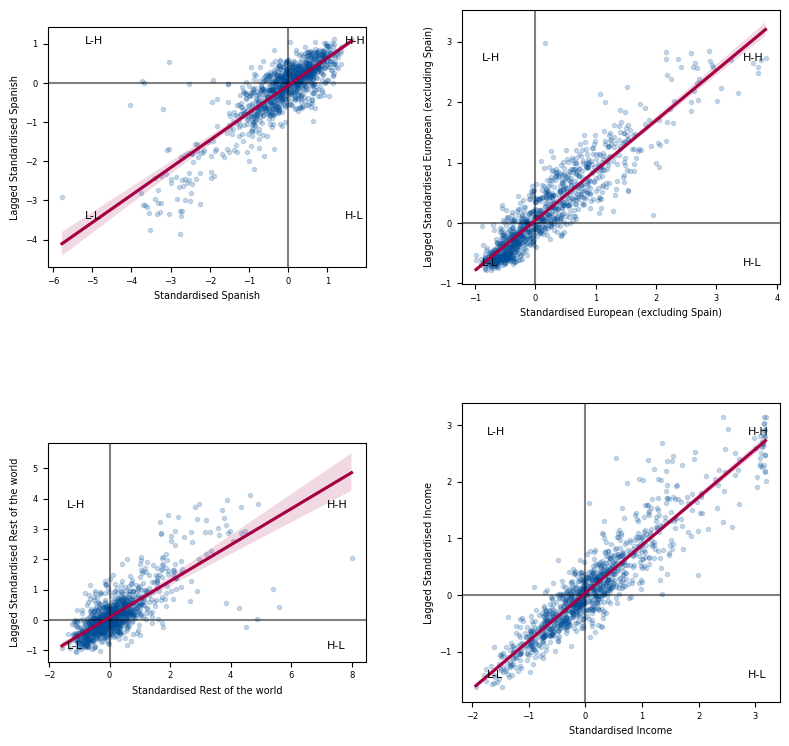

In [26]:
queen = graph.Graph.build_contiguity(join_bcn, rook=False)
# queen.summary()

queen_row = queen.transform("R")
for col in ["Spanish", "European (excluding Spain)", "Rest of the world", "Income"]:
    join_bcn[col + "_std_lag"] = queen_row.lag(join_bcn[col + "_std"])

# calculating Moran's I for each column
moran_results = {}
for col in ["Spanish", "European (excluding Spain)", "Rest of the world", "Income"]:
    moran = esda.Moran(join_bcn[col + "_std"], queen_row)
    moran_results[col] = {"Moran's I": moran.I, "p-value": moran.p_sim}

# print(moran_results)
f, ax = plt.subplots(2, 2, figsize=(8, 8))
cols = ["Spanish", "European (excluding Spain)", "Rest of the world", "Income"]
for col, subplot in zip(cols, ax.flatten()):
    subplot.set_aspect("equal")
    subplot.axvline(0, c="black", alpha=0.5)
    subplot.axhline(0, c="black", alpha=0.5)
    subplot.text(
        join_bcn[col + "_std"].max() * 0.9,
        join_bcn[col + "_std_lag"].max() * 0.9,
        "H-H",
        fontsize=8,
    )
    subplot.text(
        join_bcn[col + "_std"].max() * 0.9,
        join_bcn[col + "_std_lag"].min() * 0.9,
        "H-L",
        fontsize=8,
    )
    subplot.text(
        join_bcn[col + "_std"].min() * 0.9,
        join_bcn[col + "_std_lag"].max() * 0.9,
        "L-H",
        fontsize=8,
    )
    subplot.text(
        join_bcn[col + "_std"].min() * 0.9,
        join_bcn[col + "_std_lag"].min() * 0.9,
        "L-L",
        fontsize=8,
    )
    sns.regplot(
        x=col + "_std",
        y=col + "_std_lag",
        data=join_bcn,
        marker=".",
        color="#004d98",
        scatter_kws={"alpha": 0.2},
        line_kws=dict(color="#a50044"),
        ax=subplot,
    )
    subplot.set_xlabel("Standardised " + col, fontsize=7)
    subplot.set_ylabel("Lagged Standardised " + col, fontsize=7)

    subplot.tick_params(axis="both", which="major", labelsize=6)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.2)

To identify local clusters and outliers, Local Indicators of Spatial Association (LISAs) were computed for each variable. The resulting maps reveal distinct spatial patterns: a cluster of areas with a low proportion of Spanish nationals is found in the city centre, while clusters with predominantly Spanish populations are located in the west and north. European nationals form two main clusters—one with high proportions in the western part of the city, and another with low proportions in the north. Areas with a high proportion of non-European nationals are concentrated south of the city centre.

The western part of Barcelona stands out as a clear cluster of high disposable income, which also overlaps with areas where the proportion of non-European nationals is low.

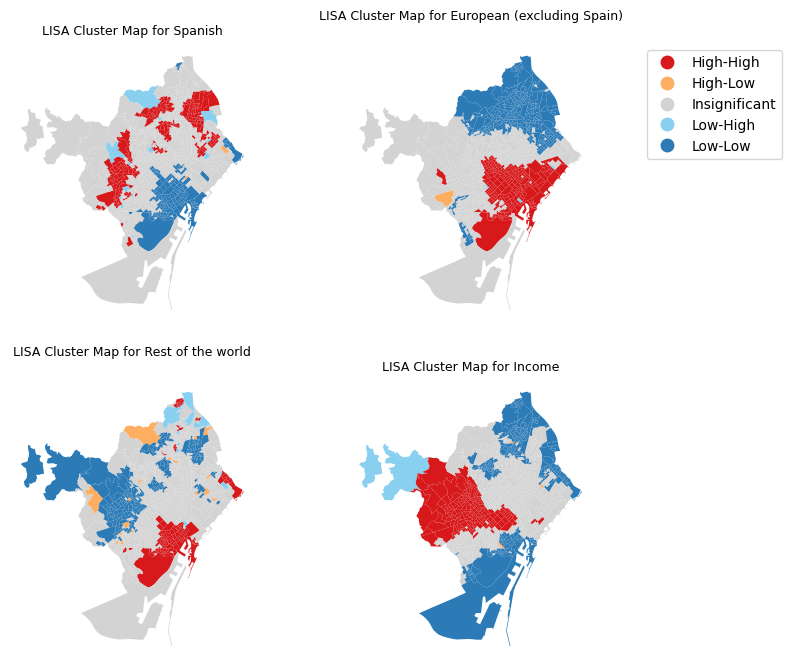

In [27]:
# calculating and plotting LISA cluster maps for all columns, with small legends to be shown
cols = ["Spanish", "European (excluding Spain)", "Rest of the world", "Income"]
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for ax, col in zip(axes.flatten(), cols):
    lisa = esda.Moran_Local(join_bcn[col + "_std"], queen_row)
    lisa.plot(join_bcn, ax=ax, legend=True)
    ax.set_title(f"LISA Cluster Map for {col}", fontsize=9)
    ax.legend_.set_bbox_to_anchor((1.8, 1))
    ax.set_axis_off()
    # remove legend of all subplots except the second one
    if col != "European (excluding Spain)":
        ax.get_legend().remove()    